Processing 1478 rows.


/Users/oscar/Desktop/Projects/birdcleff-2026/venv/lib/python3.11/site-packages/transformers/audio_utils.py:538: UserWarning: At least one mel filter has all zero values. The value for `num_mel_filters` (128) may be set too high. Or, the value for `num_frequency_bins` (257) may be set too low.
  warnings.warn(


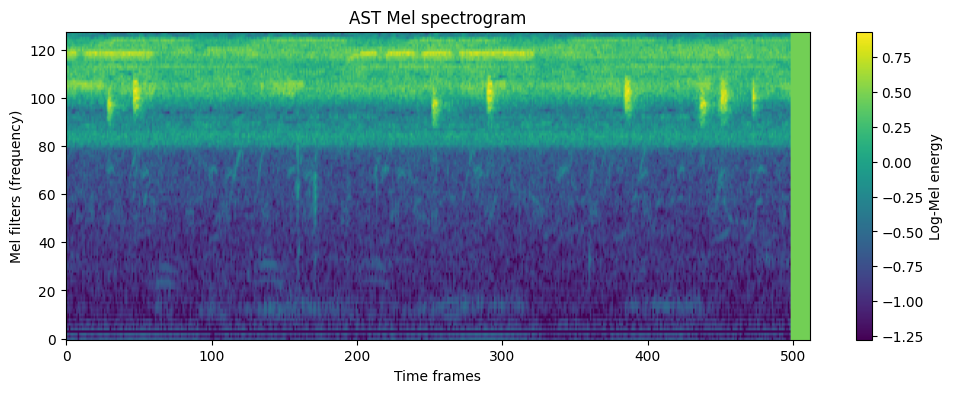

In [1]:
import matplotlib.pyplot as plt

from src.data_manager import DataManager
from src.config import Config


config = Config()
data_manager = DataManager(config)

for batch in data_manager:
    spectrogram = batch['input_values'][0]
    spectrogram = spectrogram.T.numpy()
    plt.figure(figsize=(12, 4))
    plt.imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis')
    plt.colorbar(label='Log-Mel energy')
    plt.title('AST Mel spectrogram')
    plt.xlabel('Time frames')
    plt.ylabel('Mel filters (frequency)')
    plt.show()
    break

In [11]:
import torch
import numpy as np

from transformers import ASTForAudioClassification

from src.config import Config
from src.data_manager import DataManager

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
config = Config()
data_manager = DataManager(config)
checkpoint_path = 'data/checkpoints/checkpoint-840'
model = ASTForAudioClassification.from_pretrained(checkpoint_path)
model.eval()
model.to(device)  # type: ignore

filename = 'BC2026_Train_0022_S22_20211114_014500'

with torch.no_grad():
    start_seconds, end_seconds = 15.0, 20.0
    input = data_manager.get_inference_input(
        f'./data/train_soundscapes/{filename}.ogg',
        start_seconds,
        end_seconds
    ).to(device)
    logits = model(input).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)


print(f'row_id={filename}_{int(end_seconds)}')
probs = probs[-1, :]
top_10_indxs = np.argsort(probs.detach().cpu().numpy())[-10:][::-1]
for idx in top_10_indxs:
    print(f'{data_manager.id_to_label[idx]}={probs[idx]}')

Processing 1478 rows.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

row_id=BC2026_Train_0022_S22_20211114_014500_20
compau=0.9062411785125732
litnig1=0.007661059498786926
65380=0.0062532308511435986
22967=0.005842300597578287
undtin1=0.004659183323383331
23158=0.004149575252085924
1491113=0.0036991422530263662
22973=0.0029148904141038656
555146=0.002671303926035762
24279=0.0026577382814139128
